# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import numpy as np

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | increases by 7 | multiplied by 3 |
| Median | increases by 7 | multiplied by 3 |
| Sample standard deviation | unchanged | multiplied by 3 |
| IQR | unchanged | multiplied by 3 |


**Answer:**

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | increases by 7 | multiplied by 3 |
| Median | increases by 7 | multiplied by 3 |
| Sample standard deviation | unchanged | multiplied by 3 |
| IQR | unchanged | multiplied by 3 |

### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [7]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

original_mean = x.mean()
shifted_mean = shifted.mean()
scaled_mean = scaled.mean()
print("mean:", original_mean, shifted_mean, scaled_mean)

original_std = x.std()
shifted_std = shifted.std()
scaled_std = scaled.std()
print("STD:", original_std, shifted_std, scaled_std)

original_median = x.median()
shifted_median = shifted.median()
scaled_median = scaled.median()
print("median:", original_median, shifted_median, scaled_median)

original_IQR = x.quantile(0.75) - x.quantile(0.25)
shifted_IQR = shifted.quantile(0.75) - shifted.quantile(0.25)
scaled_IQR = scaled.quantile(0.75) - scaled.quantile(0.25)

print("IQR:", original_IQR, shifted_IQR, scaled_IQR)


mean: 8.0 15.0 24.0
STD: 3.1622776601683795 3.1622776601683795 9.486832980505138
median: 8.0 15.0 24.0
IQR: 4.0 4.0 12.0


**Answer:** Agrees with my predictions

| Statistic | Original | After adding 7 | After multiplying by 3 |
|---|---|---|---|
| Mean | 8 | 15 | 24 |
| Median | 8 | 15 | 24 |
| Sample standard deviation | 3.2 | 3.2 | 9.49 |
| IQR | 4 | 4 | 12 |

## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [23]:
sepal_width = iris["sepal.width"]

q1 = sepal_width.quantile(0.25)
median = sepal_width.median()
q3 = sepal_width.quantile(0.75)

IQR = q3 - q1

print("q1:", q1, "median:", median, "q3:", q3)
print("IQR:", IQR)

lower_fence = q1 - 1.5*IQR
upper_fence = q3 + 1.5*IQR

print("fences:", lower_fence, upper_fence)

low_outliers = sepal_width < lower_fence
high_outliers = sepal_width > upper_fence

values_below = sepal_width[low_outliers]
values_above = sepal_width[high_outliers]
lower_outliers= np.flatnonzero(low_outliers)
higher_outliers= np.flatnonzero(high_outliers)

print("values below:",values_below, "indices:", lower_outliers)
print("values above:",values_above, "indices:", higher_outliers)


low_outliers_count = len(values_below)
high_outliers_count = len(values_above)
total_outliers = low_outliers_count + high_outliers_count

print("Total Outliers:", total_outliers)

q1: 2.8 median: 3.0 q3: 3.3
IQR: 0.5
fences: 2.05 4.05
values below: 60    2.0
Name: sepal.width, dtype: float64 indices: [60]
values above: 15    4.4
32    4.1
33    4.2
Name: sepal.width, dtype: float64 indices: [15 32 33]
Total Outliers: 4


**Answer:**
1. q1 = 2.8, median = 3.0, q3 = 3.3
2. IQR = 0.5
3. lower fence = 2.05, upper fence = 4.05
4. Indices: 15, 32, 33, and 60 fall outside these fences
5. 1 low outlier and 3 high outliers for a total of 4

## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


Text(0.5, 1.0, 'Histogram of Sepal Length with 6 bins')

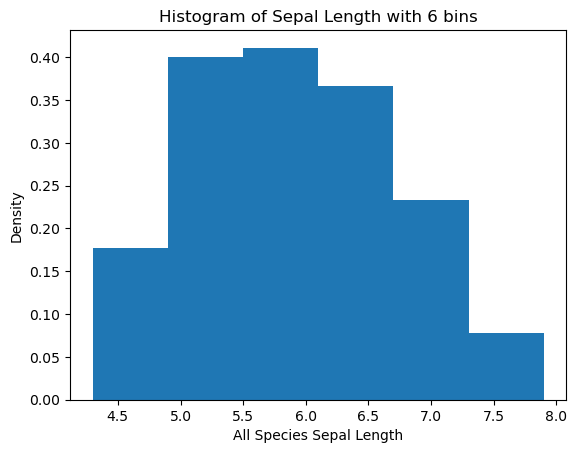

In [28]:
sepal_length = iris["sepal.length"]

plt.hist(sepal_length, bins=6, density=True)
plt.xlabel("All Species Sepal Length")
plt.ylabel("Density")
plt.title("Histogram of Sepal Length with 6 bins")

Text(0.5, 1.0, 'Histogram of Sepal Length with 18 bins')

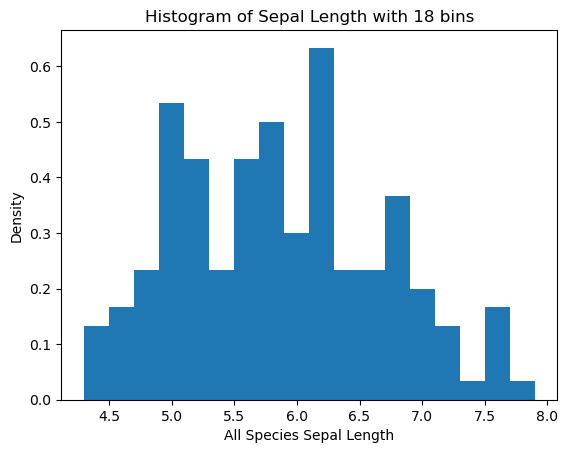

In [29]:
sepal_length = iris["sepal.length"]

plt.hist(sepal_length, bins=18, density=True)
plt.xlabel("All Species Sepal Length")
plt.ylabel("Density")
plt.title("Histogram of Sepal Length with 18 bins")

**Answer:**
Both histograms have a slight tail that points to the right. With only 6 bins, the data looks to be distributed more evenly around 5.5 - 6.0, but the 18 bin plot shows a wider distribution around the center of the data spread.

### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [32]:
# Useful pattern:
# iris.groupby("variety")["sepal.length"].agg([...])

iris.groupby("variety")["sepal.length"].agg(["count", "median", "std", "min", "max"])

,count,median,std,min,max
variety,,,,,
Setosa,50,5.0,0.352490,4.3,5.8
Versicolor,50,5.9,0.516171,4.9,7.0
Virginica,50,6.5,0.635880,4.9,7.9


**Answer:**
The largest median sepal length belongs to Virginica. It also has the largest sample standard deviation.

### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


Text(0, 0.5, 'Sepal length')

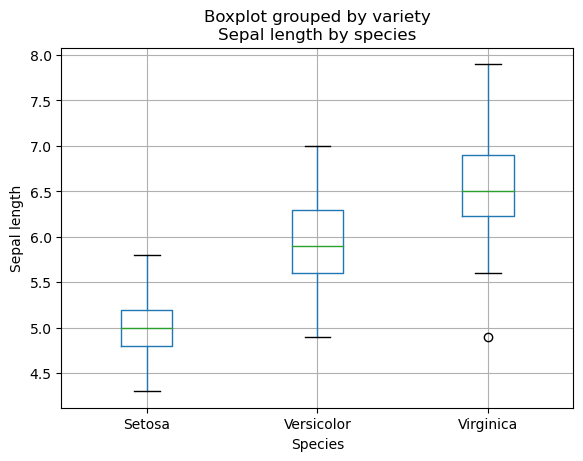

In [34]:
# Useful pattern:
# iris.boxplot(column="...", by="...")

box = iris.boxplot(column="sepal.length", by="variety")
box.set_title("Sepal length by species")
box.set_xlabel("Species")
box.set_ylabel("Sepal length")

**Answer:**
The boxplots show the center of the sepal length for each species increases as we move from Setosa, to Versicolor, to Virginica, respectively. It also shows that Setosa has the smallest/tightest spread of data while Virginica has the largest. Virginica is also the only species with an outlier.

## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [35]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)

comparison

# Useful pattern:
# comparison.agg(["mean", "median", "std"])

comparison.agg(["mean", "median", "std"])


,A,B
mean,5.000000,5.000000
median,5.000000,5.000000
std,2.738613,2.738613


### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


Text(0, 0.5, 'Value')

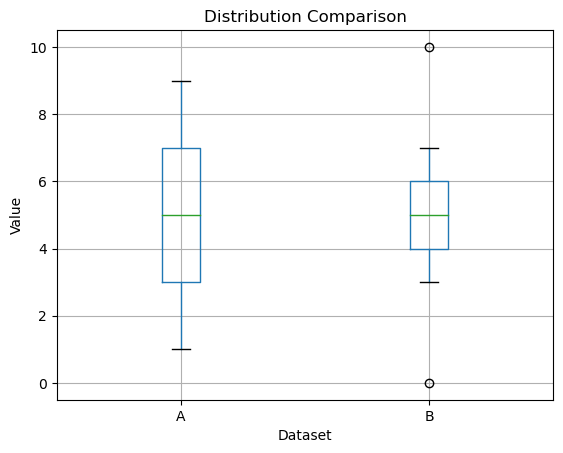

In [40]:
box = comparison.boxplot()

box.set_title("Distribution Comparison")
box.set_xlabel("Dataset")
box.set_ylabel("Value")

### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:**

The distribution/spread between the two datasets are significantly differnet, despite having the same mean, median, and STD. Dataset B has a tighter IQR with a lower and upper outlier, while dataset A is more spread out with no outliers. This can not be understood just from the numerical summaries originally calculated in part A. Without the box plots, the numerical summaries of the datasets would make them appear identical.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-15",
  "messages": [
    {"i": 1, "who": "student", "text": "for LE2-3 A, should I be plotting the histograms for all sepal.length data, or should I separate it by species?"},
    {"i": 2, "who": "tutor", "text": "All of it — one pooled `sepal.length` histogram, plotted twice with different `bins`. The prompt says \"two histograms of the **same** `sepal.length` data,\" so the only thing that changes between the two plots is the bin count. That's the point of the part: same data, different resolution.\n\nSplitting by species comes later, in LE2-3B (grouped summary) and LE2-3C (boxplot by `variety`).\n\nGood instinct to check the scope before plotting — that's the kind of thing that's annoying to discover after you've written the cell. Anything else on the histogram setup?"},
    {"i": 3, "who": "student", "text": "can you explain what .agg() does when using group by ?"},
    {"i": 4, "who": "tutor", "text": "Sure. `.groupby()` and `.agg()` work as a pair: `groupby` splits the rows into groups, and `.agg()` collapses each group down to one row of summary numbers.\n\nThe sequence is: **split → apply → combine.** `groupby(\"group\")` splits the rows by the values in that column. Selecting a column after it (`[\"value\"]`) says which numbers you want summarized. Then `.agg()` applies each requested summary to each group separately, and pandas reassembles the results into a new DataFrame — one row per group, one column per summary.\n\n[trimmed: generic worked example on a made-up store/units DataFrame showing `sales.groupby(\"store\")[\"units\"].agg([\"count\", \"mean\", \"max\"])` and its output]\n\nA few things worth knowing:\n\n- The strings are method names. `\"mean\"`, `\"median\"`, `\"std\"`, `\"min\"`, `\"max\"`, `\"count\"`, `\"sum\"` all work because pandas looks up the matching Series method. Passing a list gives you one column per name, in the order you listed them.\n- The group values become the index. `.reset_index()` turns it back into a regular column if you want that.\n- `.agg(\"std\")` gives the sample standard deviation (`ddof=1`), same as `.std()`. If you instead pass the NumPy function `np.std`, you get the population version (`ddof=0`) and your number will come out slightly smaller. Stick with the string.\n- `.agg()` on the whole DataFrame (no column selected) applies the summaries to every numeric column, giving a wider result with multi-level column labels. Selecting one column first keeps it flat and readable.\n- `\"count\"` counts non-missing values, so it can be smaller than the group size if there are `NaN`s.\n\nYou can also pass a dict to summarize different columns differently, e.g. `.agg({\"units\": \"sum\", \"price\": \"mean\"})`, though you won't need that here.\n\nThat's a useful thing to have asked about — `groupby` plus `agg` is the workhorse for the rest of the course. Want me to go into how the aggregation names map onto the five summaries the prompt asks for, or anything about the index?"}
  ],
  "events": [],
  "parts": [
    {"part": "2-3A", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "2-3B", "exchanges": 1, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "No stalling in this session. Both student messages were orientation and concept questions rather than stuck points: whether LE2-3A histograms use pooled or species-split data, and what `.agg()` does in combination with `groupby`. No code was posted and no step was completed, so neither 2-3A nor 2-3B has been attempted in the notebook yet.",
    "No unstuck declarations and no release-valve use. Nothing here suggests a tutoring failure; the session was short and consisted entirely of free explanation requests answered directly."
  ]
}

*(session records go here)*


## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
